# M1: FM100 loading, scoring, and plotting

`PLANScores.md` M1: the Farnsworth-Munsell 100 Hue test asks each
participant to arrange 85 caps in hue order; deviations from the correct
order are scored several ways -- Total Error Score (TES), Partial Error
Scores split by axis (PES red-green / blue-yellow), tray-level TES, and the
Vingrys-King-Smith (VKS) confusion-ellipse metrics. Raw data:
`/home/sebas/data/standardizedScores/repeatedSessionsPY.txt` (read in
place), 69 (subject, session) rows after dropping one duplicated row --
subjects are the same MET* IDs as `ssveps/` and `beh/`, group/subgroup
looked up live from `ssveps/files/metadata.csv`.

`scripts/scores.py` is a refactor of `templateCode/FM100.py`'s scoring
math (not a rewrite) -- `tests/test_fm100.py` pins every function's output
against the original template on all 69 real rows, bit-for-bit.

In [1]:
import sys
sys.path.append('../scripts')

import pandas as pd

import loader
import scores
import plotting

df = loader.load_fm100_raw()
score_table = scores.build_scores(df)

df.groupby(['group', 'subgroup'])['sub_id'].nunique()

group    subgroup
CTR      NA          21
CVD      deutan       7
         protan       8
HD       NA           1
PD       NA           6
UNKNOWN  NA           5
Name: sub_id, dtype: int64

## MET047 and MET021

MET047 has no SSVEP or behavioral data at all -- entirely new to this
dataset, group 'UNKNOWN'. MET021 is labeled CTR in `ssveps/`'s metadata
and kept as-is here, but was flagged as possibly having a different
(non-red-green) deficiency.

In [2]:
score_table[score_table['sub_id'].isin(['MET047', 'MET021'])][['sub_id', 'session', 'group', 'TES', 'PES_RG', 'PES_BY', 'VKS_Angle']]

,sub_id,session,group,TES,PES_RG,PES_BY,VKS_Angle
34,MET021,1,CTR,96.0,22.0,71.0,60.058109
35,MET021,2,CTR,64.0,28.0,36.0,69.461244
68,MET047,1,UNKNOWN,216.0,104.0,108.0,55.625668


MET021's TES (96, 64 across two sessions) sits well above the CTR group
mean (~49) -- consistent with the suspicion their HC label doesn't fully
fit. MET047's TES (216) is comparable to the CVD group mean (~215), but
unlike protan/deutan (whose PES_RG consistently exceeds PES_BY -- see the
group table below), MET047's PES_RG (104) and PES_BY (108) are roughly
balanced. That's consistent with a real hue confusion that isn't the
classic red-green pattern -- worth the "different type of deficiency" test
case you flagged them as.

## Group scores: PES_RG vs. PES_BY by group/subgroup

Protan and deutan both show PES_RG clearly exceeding PES_BY, the classic
red-green-deficiency signature; PD and UNKNOWN don't show that lopsided
pattern.

In [3]:
score_table.groupby(['group', 'subgroup'])[['TES', 'PES_RG', 'PES_BY', 'VKS_Angle', 'VKS_Sindex']].mean()

TES      PES_RG     PES_BY  VKS_Angle  VKS_Sindex
group   subgroup                                                          
CTR     NA         48.571429   19.457143  28.457143  50.259211    1.349792
CVD     deutan    238.285714  138.142857  96.285714 -11.968136    1.542385
        protan    196.000000  127.222222  67.444444  27.558443    1.426579
HD      NA         66.000000   26.500000  39.500000  49.420107    1.388935
PD      NA        146.909091   61.636364  82.909091  57.667685    1.419702
UNKNOWN NA        131.200000   57.200000  70.800000  53.751422    1.383639

## One participant: linear and radial error profiles

Linear: cap position (1-85) on x, circular hue error on y. Radial: the same
profile wrapped onto a circle (the "trademark" FM100 diagram) -- angle=cap
position, radius=error. One line per session, colored.

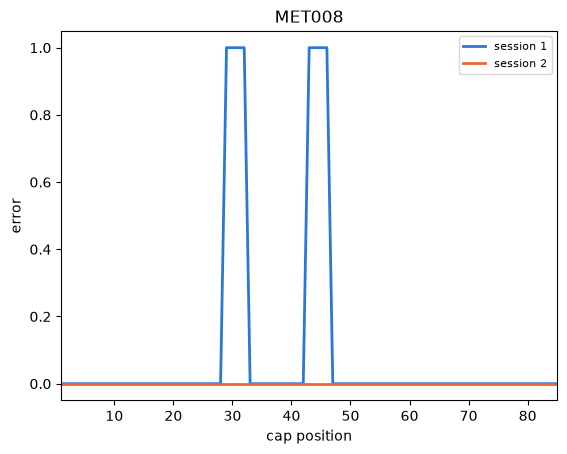

In [4]:
plotting.plot_subject_fm100(df, 'MET008', kind='linear');

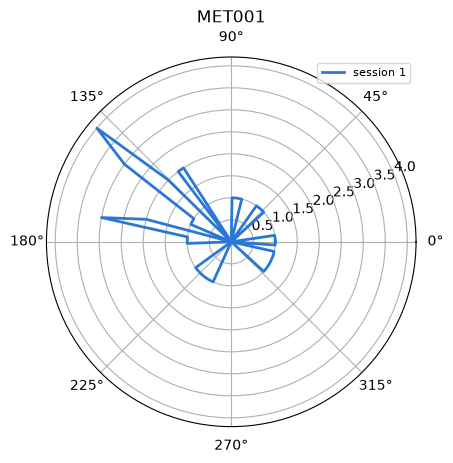

In [5]:
plotting.plot_subject_fm100(df, 'MET001', kind='radial');

### Gentle filtering: a circular moving average

`window=` smooths cap-to-cap noise in the error profile while preserving
its overall shape -- the smoothing wraps around the hue circle, since a cap
near position 85 is a real neighbor of a cap near position 1.

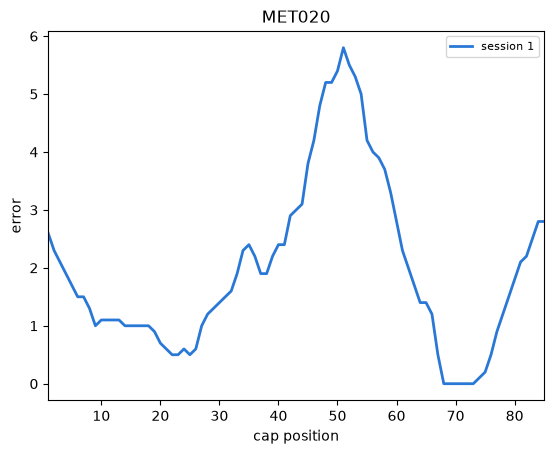

In [7]:
plotting.plot_subject_fm100(df, 'MET020', kind='linear', window=10);

## Group plots, with ±1 SD variability shading

Each subject contributes one profile (their own sessions averaged first, so
a 3-session subject doesn't outweigh a 1-session one) to that category's
mean line and ±1 SD band. A line chart, so all 5 categories go on one panel
in fixed color order -- no 3-category cap here (see `plotting.py`'s module
docstring for why that differs from `beh/`'s scatter plots).

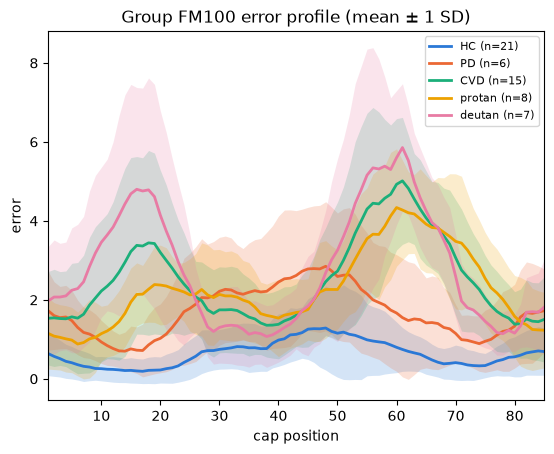

In [8]:
categories = [
    {'label': 'HC', 'group': 'CTR'},
    {'label': 'PD', 'group': 'PD'},
    {'label': 'CVD', 'group': 'CVD'},
    {'label': 'protan', 'subgroup': 'protan'},
    {'label': 'deutan', 'subgroup': 'deutan'},
]
plotting.plot_group_fm100(df, categories, window=10);

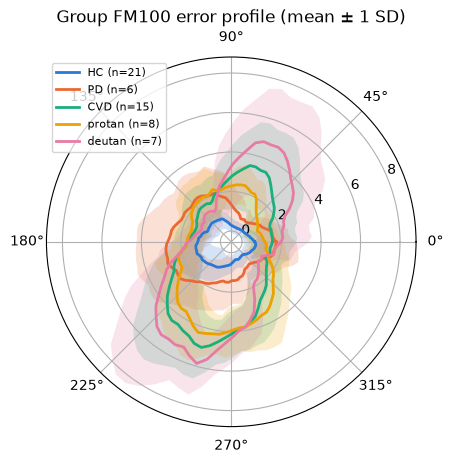

In [9]:
plotting.plot_group_fm100(df, categories, kind='radial', window=10);

Protan and deutan's bands sit clearly above HC's across most of the circle
and separate from each other in some regions (consistent with the axis-wise
PES split above), while PD sits between HC and the CVD subtypes -- a
first visual look consistent with the group TES/PES table.

## An arbitrary hand-picked set of participants

`sub_ids=` works the same way here as in `beh/`/`ssveps/` -- pass an
explicit list instead of a group/subgroup filter. MET047 and MET021 --
your two "different type of deficiency" test cases -- grouped together
against protan/deutan for context.

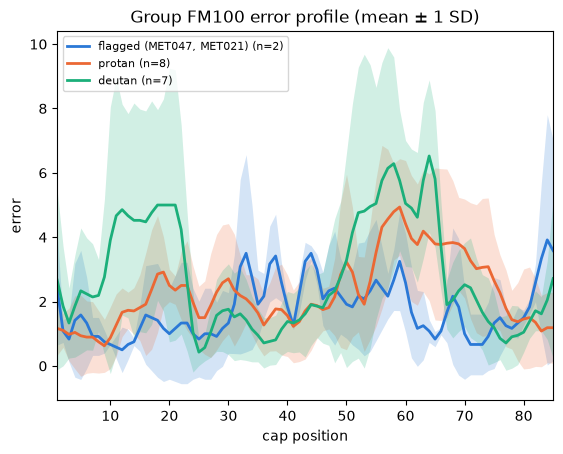

In [9]:
plotting.plot_group_fm100(df, [
    {'label': 'flagged (MET047, MET021)', 'sub_ids': ['MET047', 'MET021']},
    {'label': 'protan', 'subgroup': 'protan'},
    {'label': 'deutan', 'subgroup': 'deutan'},
], window=3);